# Visualização de Dados — Desafio Analista de Dados | Sefaz Maceió

Este notebook consome os dados já consolidados em `finbra.duckdb` (gerado na etapa de
carga) e produz visualizações dos indicadores calculados na etapa de análise:

1. Completude dos dados por ano
2. Ranking de capitais por taxa de execução financeira
3. Gasto per capita em Saúde e Educação
4. Maceió vs. média das capitais (evolução 2020-2024)
5. Subfunções de Saúde — onde se concentra o gasto

Pré-requisito: ter rodado os scripts `01` a `04` antes (o arquivo `finbra.duckdb` precisa
existir na raiz do projeto).

## Setup

In [ ]:
pip install matplotlib

In [ ]:
pip install seaborn

In [4]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

con = duckdb.connect("../finbra.duckdb")

# Cor de destaque para Maceió em todos os gráficos
COR_MACEIO = "#1f77b4"
COR_DEMAIS = "#c7c7c7"

## 1. Completude dos dados por ano

Antes de qualquer comparação, é importante visualizar quantas capitais reportaram dados em
cada ano evidenciando o motivo por qual 2025 não entra nas comparações posteriores.

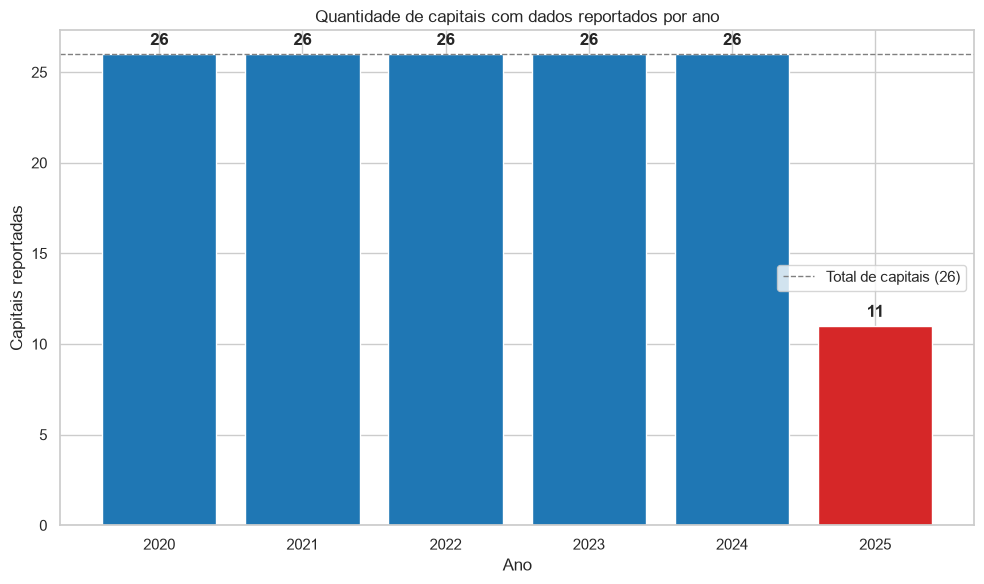

In [6]:
completude = con.execute("""
    SELECT ano, COUNT(DISTINCT \"Instituição\") AS qtd_capitais
    FROM despesas
    GROUP BY ano
    ORDER BY ano
""").fetchdf()

fig, ax = plt.subplots()
cores = [COR_MACEIO if qtd == 26 else "#d62728" for qtd in completude["qtd_capitais"]]
ax.bar(completude["ano"].astype(str), completude["qtd_capitais"], color=cores)
ax.axhline(26, color="gray", linestyle="--", linewidth=1, label="Total de capitais (26)")
ax.set_title("Quantidade de capitais com dados reportados por ano")
ax.set_xlabel("Ano")
ax.set_ylabel("Capitais reportadas")
ax.legend()

for i, v in enumerate(completude["qtd_capitais"]):
    ax.text(i, v + 0.5, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../resultados/grafico_01_completude.png", dpi=150)
plt.show()

**Leitura:** 2020 a 2024 têm as 26 capitais completas. 2025 está em vermelho, destacando que
está incompleto (11 capitais) por isso fica de fora das comparações de evolução temporal e
per capita.

## 2. Ranking de capitais por taxa de execução financeira média

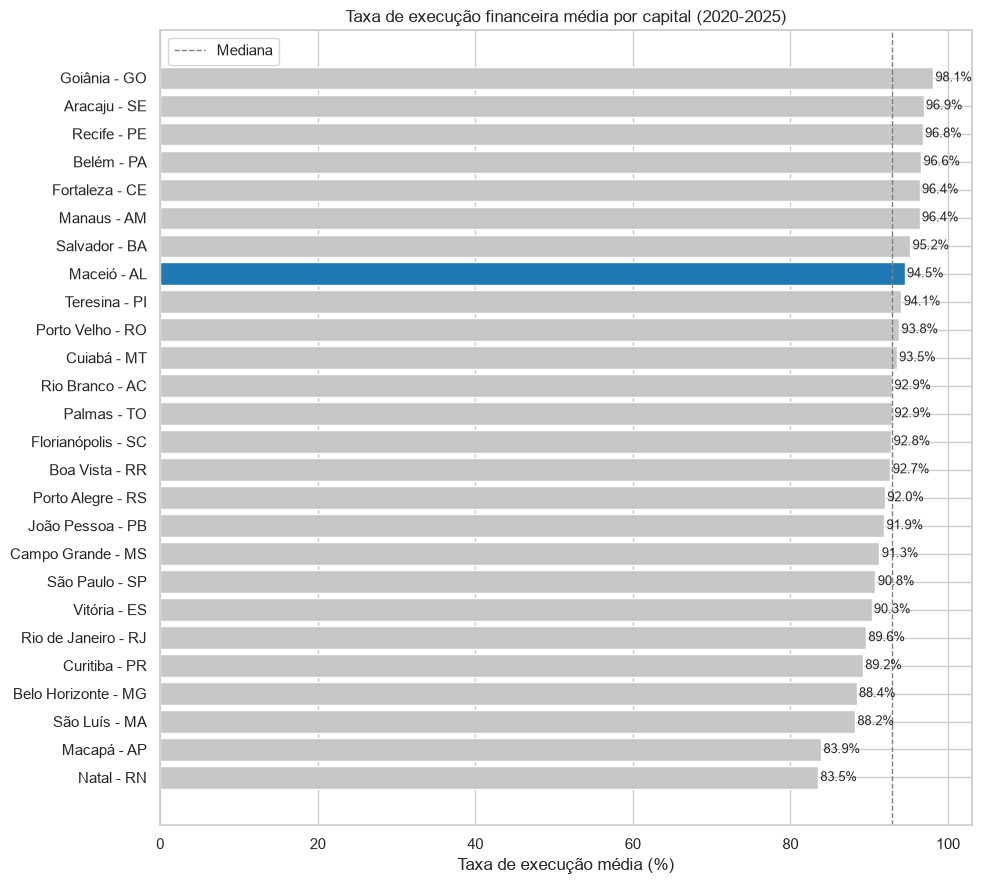

In [11]:
ranking = con.execute("""
    WITH empenhado AS (
        SELECT \"Instituição\", ano, SUM(\"Valor\") AS valor_empenhado
        FROM despesas
        WHERE \"Coluna\" = 'Despesas Empenhadas' AND tipo_conta = 'funcao'
        GROUP BY \"Instituição\", ano
    ),
    pago AS (
        SELECT \"Instituição\", ano, SUM(\"Valor\") AS valor_pago
        FROM despesas
        WHERE \"Coluna\" = 'Despesas Pagas' AND tipo_conta = 'funcao'
        GROUP BY \"Instituição\", ano
    )
    SELECT
        e.\"Instituição\" AS capital,
        ROUND(AVG(p.valor_pago / NULLIF(e.valor_empenhado, 0) * 100), 1) AS taxa_execucao_media_pct
    FROM empenhado e
    JOIN pago p ON e.\"Instituição\" = p.\"Instituição\" AND e.ano = p.ano
    GROUP BY e.\"Instituição\"
    ORDER BY taxa_execucao_media_pct DESC
""").fetchdf()

# Simplifica o nome da capital para caber melhor no eixo
ranking["capital_curto"] = (
    ranking["capital"]
    .str.replace("Prefeitura Municipal de ", "", regex=False)
    .str.replace("Prefeitura Municipal do ", "", regex=False)
)

cores = [COR_MACEIO if "Maceió" in c else COR_DEMAIS for c in ranking["capital"]]

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(ranking["capital_curto"], ranking["taxa_execucao_media_pct"], color=cores)
ax.invert_yaxis()  # maior no topo
ax.set_title("Taxa de execução financeira média por capital (2020-2025)")
ax.set_xlabel("Taxa de execução média (%)")
ax.axvline(ranking["taxa_execucao_media_pct"].median(), color="gray", linestyle="--",
           linewidth=1, label="Mediana")
ax.legend()

for i, valor in enumerate(ranking["taxa_execucao_media_pct"]):
    ax.text(valor + 0.3, i, f"{valor}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../resultados/grafico_02_ranking_execucao.png", dpi=150)
plt.show()

**Leitura:** Maceió (destacada em azul) aparece em 8º lugar, com taxa de execução acima da
mediana das 26 capitais — indício de uma execução orçamentária relativamente consistente entre
o que é empenhado e o que é efetivamente pago.

## 3. Gasto per capita: Saúde e Educação (2024)

Comparação lado a lado, destacando a posição de Maceió em cada área.

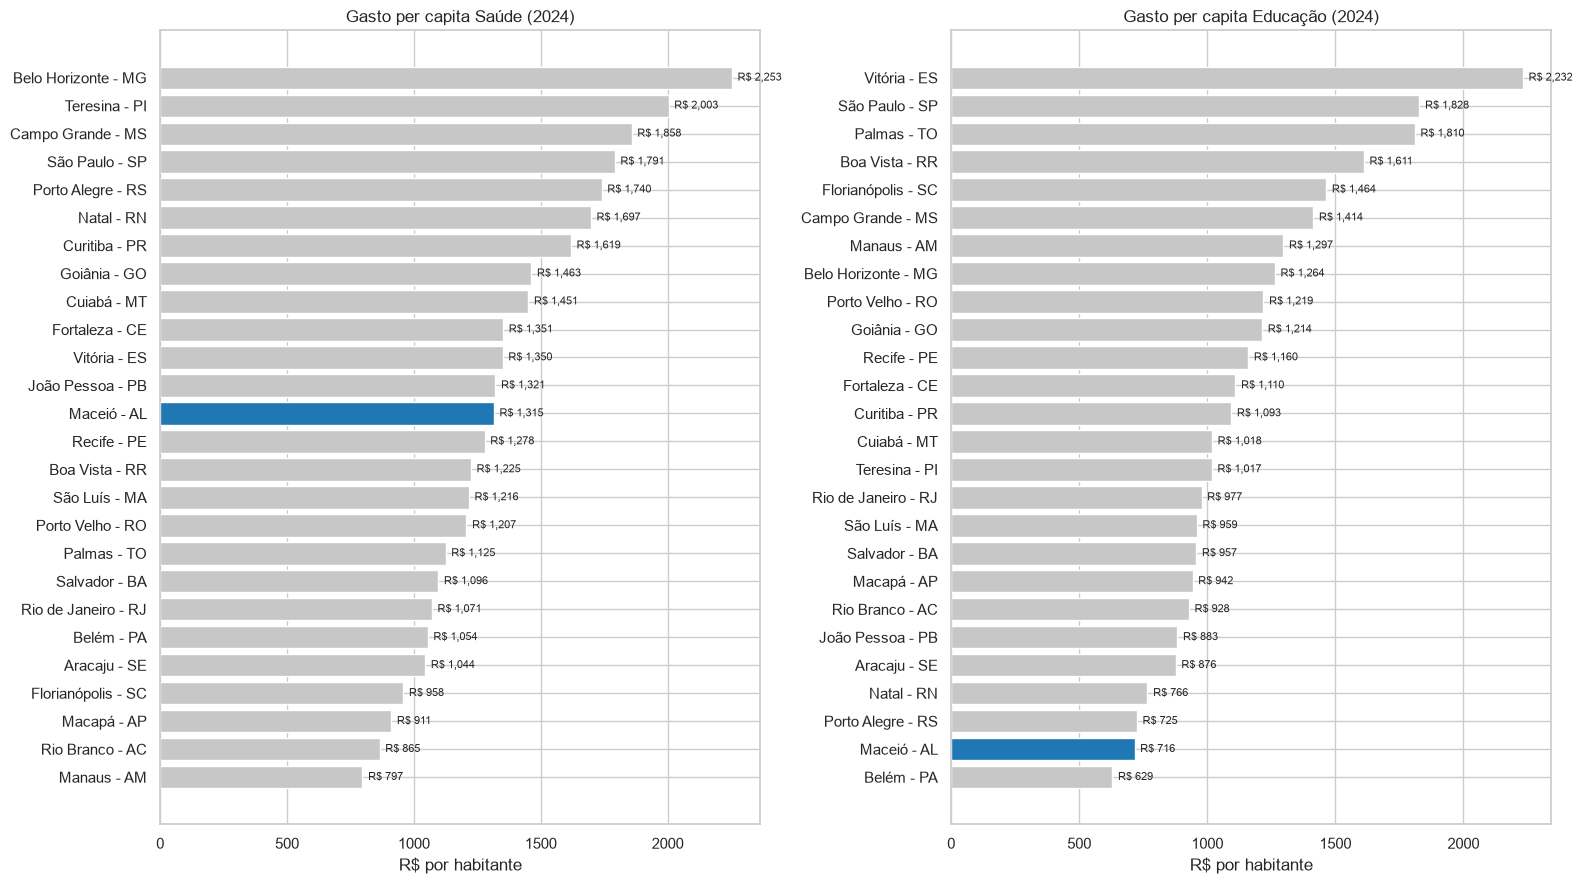

In [13]:
per_capita = con.execute("""
    SELECT
        \"Instituição\" AS capital,
        \"Conta\" AS funcao,
        \"População\" AS populacao,
        SUM(\"Valor\") AS total_pago,
        ROUND(SUM(\"Valor\") / NULLIF(\"População\", 0), 2) AS gasto_per_capita
    FROM despesas
    WHERE \"Coluna\" = 'Despesas Pagas'
      AND tipo_conta = 'funcao'
      AND ano = 2024
      AND (\"Conta\" LIKE '10 -%' OR \"Conta\" LIKE '12 -%')
    GROUP BY \"Instituição\", \"Conta\", \"População\"
""").fetchdf()

per_capita["capital_curto"] = (
    per_capita["capital"]
    .str.replace("Prefeitura Municipal de ", "", regex=False)
    .str.replace("Prefeitura Municipal do ", "", regex=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

for ax, funcao_nome, titulo in zip(
    axes, ["10 - Saúde", "12 - Educação"], ["Saúde", "Educação"]
):
    df_f = per_capita[per_capita["funcao"] == funcao_nome].sort_values(
        "gasto_per_capita", ascending=True
    )
    cores = [COR_MACEIO if "Maceió" in c else COR_DEMAIS for c in df_f["capital"]]
    ax.barh(df_f["capital_curto"], df_f["gasto_per_capita"], color=cores)
    ax.set_title(f"Gasto per capita {titulo} (2024)")
    ax.set_xlabel("R$ por habitante")
    for i, valor in enumerate(df_f["gasto_per_capita"]):
        ax.text(valor + df_f["gasto_per_capita"].max() * 0.01, i, f"R$ {valor:,.0f}",
                va="center", fontsize=8) 

plt.tight_layout()
plt.savefig("../resultados/grafico_03_per_capita_saude_educacao.png", dpi=150)
plt.show()

**Leitura:** Maceió aparece no meio da tabela em Saúde, mas próxima da base em Educação, evidenciando uma possível lacuna de investimento educacional
por habitante em comparação às demais capitais.

## 4. Maceió vs. média das capitais: Evolução 2020-2024

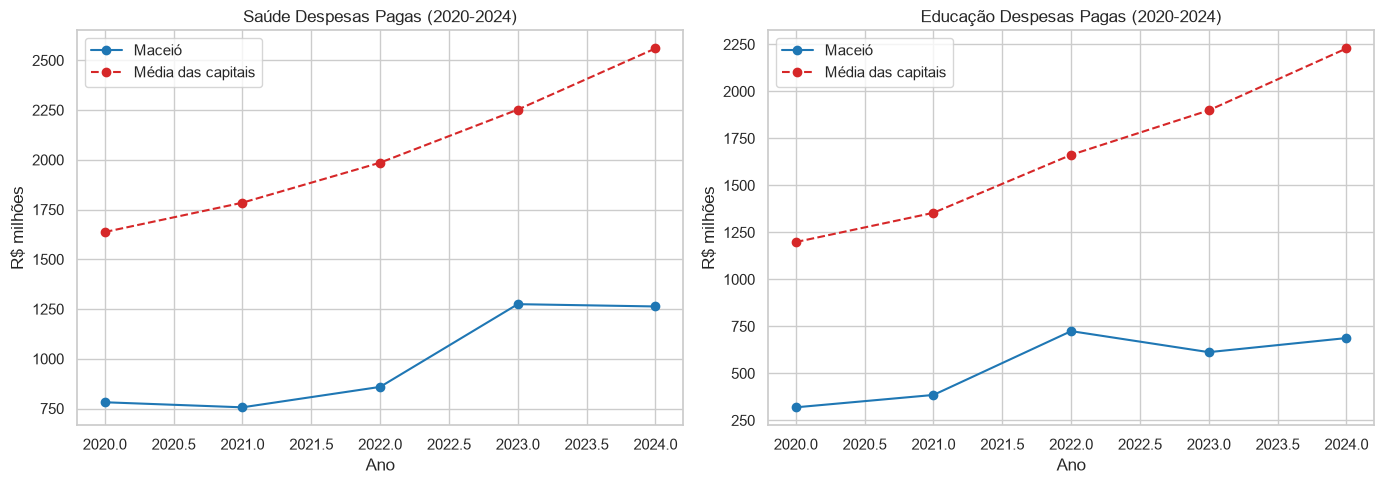

In [14]:
evolucao = con.execute("""
    SELECT
        ano,
        \"Conta\" AS funcao,
        SUM(CASE WHEN \"Instituição\" LIKE '%Maceió%' THEN \"Valor\" ELSE 0 END) AS maceio_pago,
        ROUND(AVG(\"Valor\"), 2) AS media_capitais_pago
    FROM despesas
    WHERE \"Coluna\" = 'Despesas Pagas'
      AND tipo_conta = 'funcao'
      AND (\"Conta\" LIKE '10 -%' OR \"Conta\" LIKE '12 -%')
      AND ano BETWEEN 2020 AND 2024
    GROUP BY ano, \"Conta\"
    ORDER BY \"Conta\", ano
""").fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, funcao_nome, titulo in zip(
    axes, ["10 - Saúde", "12 - Educação"], ["Saúde", "Educação"]
):
    df_f = evolucao[evolucao["funcao"] == funcao_nome]
    ax.plot(df_f["ano"], df_f["maceio_pago"] / 1e6, marker="o", label="Maceió", color=COR_MACEIO)
    ax.plot(df_f["ano"], df_f["media_capitais_pago"] / 1e6, marker="o",
            label="Média das capitais", color="#d62728", linestyle="--")
    ax.set_title(f"{titulo} Despesas Pagas (2020-2024)")
    ax.set_xlabel("Ano")
    ax.set_ylabel("R$ milhões")
    ax.legend()

plt.tight_layout()
plt.savefig("../resultados/grafico_04_evolucao_maceio_vs_media.png", dpi=150)
plt.show()

**Leitura:** em ambas as áreas, Maceió acompanha a tendência de crescimento das demais
capitais, mas em patamar de valor absoluto bem mais baixo, possivelmente por conta do porte
populacional, mas a distância proporcional entre as curvas vale observação.

## 5. Subfunções de Saúde

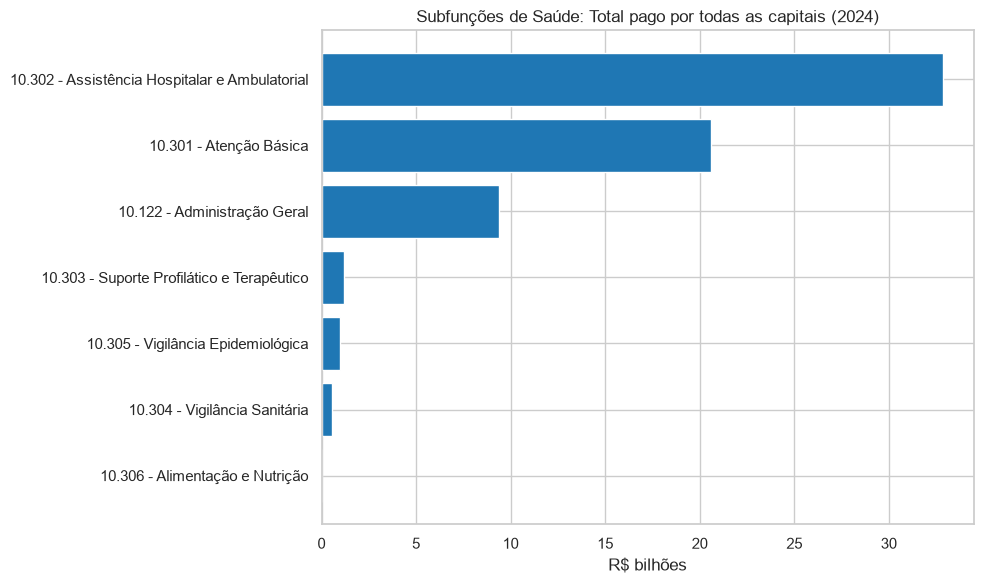

In [15]:
subfuncoes_saude = con.execute("""
    SELECT
        \"Conta\" AS subfuncao,
        SUM(\"Valor\") AS total_pago
    FROM despesas
    WHERE \"Coluna\" = 'Despesas Pagas'
      AND tipo_conta = 'subfuncao'
      AND \"Conta\" LIKE '10.%'
      AND ano = 2024
    GROUP BY \"Conta\"
    ORDER BY total_pago DESC
""").fetchdf()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(subfuncoes_saude["subfuncao"], subfuncoes_saude["total_pago"] / 1e9, color=COR_MACEIO)
ax.invert_yaxis()
ax.set_title("Subfunções de Saúde: Total pago por todas as capitais (2024)")
ax.set_xlabel("R$ bilhões")

plt.tight_layout()
plt.savefig("../resultados/grafico_05_subfuncoes_saude.png", dpi=150)
plt.show()

**Leitura:** Assistência Hospitalar e Ambulatorial concentra quase o dobro do gasto de Atenção
Básica entre todas as capitais.

## Encerramento

In [16]:
con.close()